## Import Libraries

This section imports the libraries required for:

- Data handling
- Data visualization
- Data preprocessing
- Model training
- Model evaluation

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Load the Dataset

Read the renewable energy dataset into a Pandas DataFrame.

In [71]:
df = pd.read_csv("Energy Production Dataset.csv")

# Display the First Rows

Display the first five rows to understand the structure of the dataset.

In [72]:
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387


# Dataset Shape

Display the number of rows and columns.

In [73]:
df.shape

(51864, 9)

# Feature Names

Display all column names in the dataset.

In [74]:
df.columns

Index(['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name',
       'Month_Name', 'Season', 'Production'],
      dtype='object')

# Data Information

Check data types and identify missing values.

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


# Missing Values

Check whether the dataset contains missing values.

In [76]:
df.isnull().sum()

Date           0
Start_Hour     0
End_Hour       0
Source         0
Day_of_Year    0
Day_Name       0
Month_Name     0
Season         0
Production     0
dtype: int64

## Feature Engineering

Create new features to improve the forecasting model performance.

In [77]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [78]:
df["Date"] = pd.to_datetime(df["Date"])

In [79]:
df = df.sort_values(["Date", "Start_Hour"]).reset_index(drop=True)

In [80]:
df["Lag_1"] = df["Production"].shift(1)

In [81]:
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production,Year,Month,Day,Lag_1
0,2020-01-01,0,1,Wind,1,Wednesday,January,Winter,3542,2020,1,1,NaN
1,2020-01-01,1,2,Wind,1,Wednesday,January,Winter,2932,2020,1,1,3542.0
2,2020-01-01,2,3,Wind,1,Wednesday,January,Winter,2725,2020,1,1,2932.0
3,2020-01-01,3,4,Wind,1,Wednesday,January,Winter,2761,2020,1,1,2725.0
4,2020-01-01,4,5,Wind,1,Wednesday,January,Winter,2708,2020,1,1,2761.0


In [82]:
df = df.dropna().reset_index(drop=True)

# Convert Date Column

Convert the Date column into datetime format for time-based analysis.

In [83]:
df["Date"] = pd.to_datetime(df["Date"])

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51863 entries, 0 to 51862
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         51863 non-null  datetime64[ns]
 1   Start_Hour   51863 non-null  int64         
 2   End_Hour     51863 non-null  int64         
 3   Source       51863 non-null  object        
 4   Day_of_Year  51863 non-null  int64         
 5   Day_Name     51863 non-null  object        
 6   Month_Name   51863 non-null  object        
 7   Season       51863 non-null  object        
 8   Production   51863 non-null  int64         
 9   Year         51863 non-null  int32         
 10  Month        51863 non-null  int32         
 11  Day          51863 non-null  int32         
 12  Lag_1        51863 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(3), int64(4), object(4)
memory usage: 4.6+ MB


# Energy Production Over Time

Visualize how energy production changes over time.

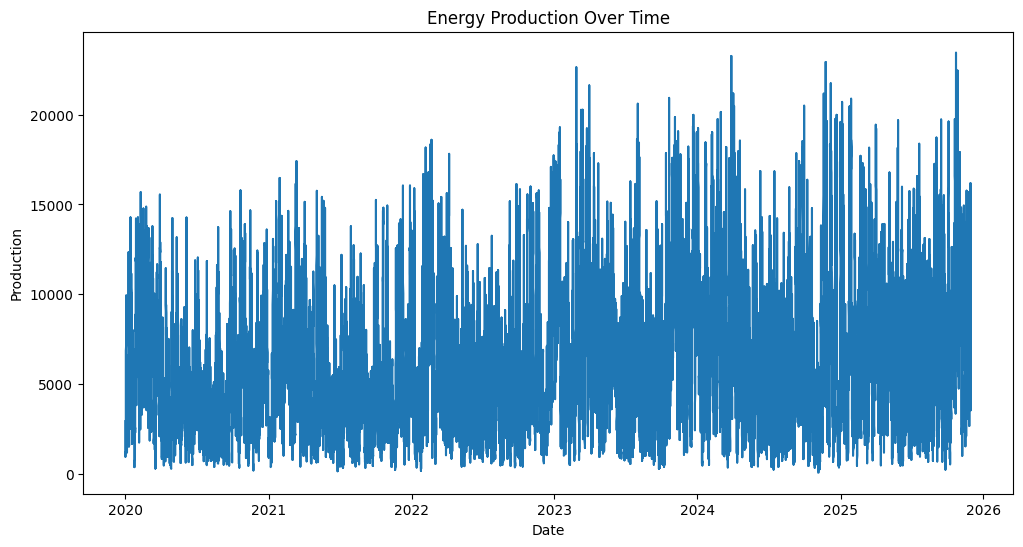

In [85]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Production"])

plt.title("Energy Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")

plt.show()

# Distribution of Numerical Features

Visualize the distribution of numerical variables.

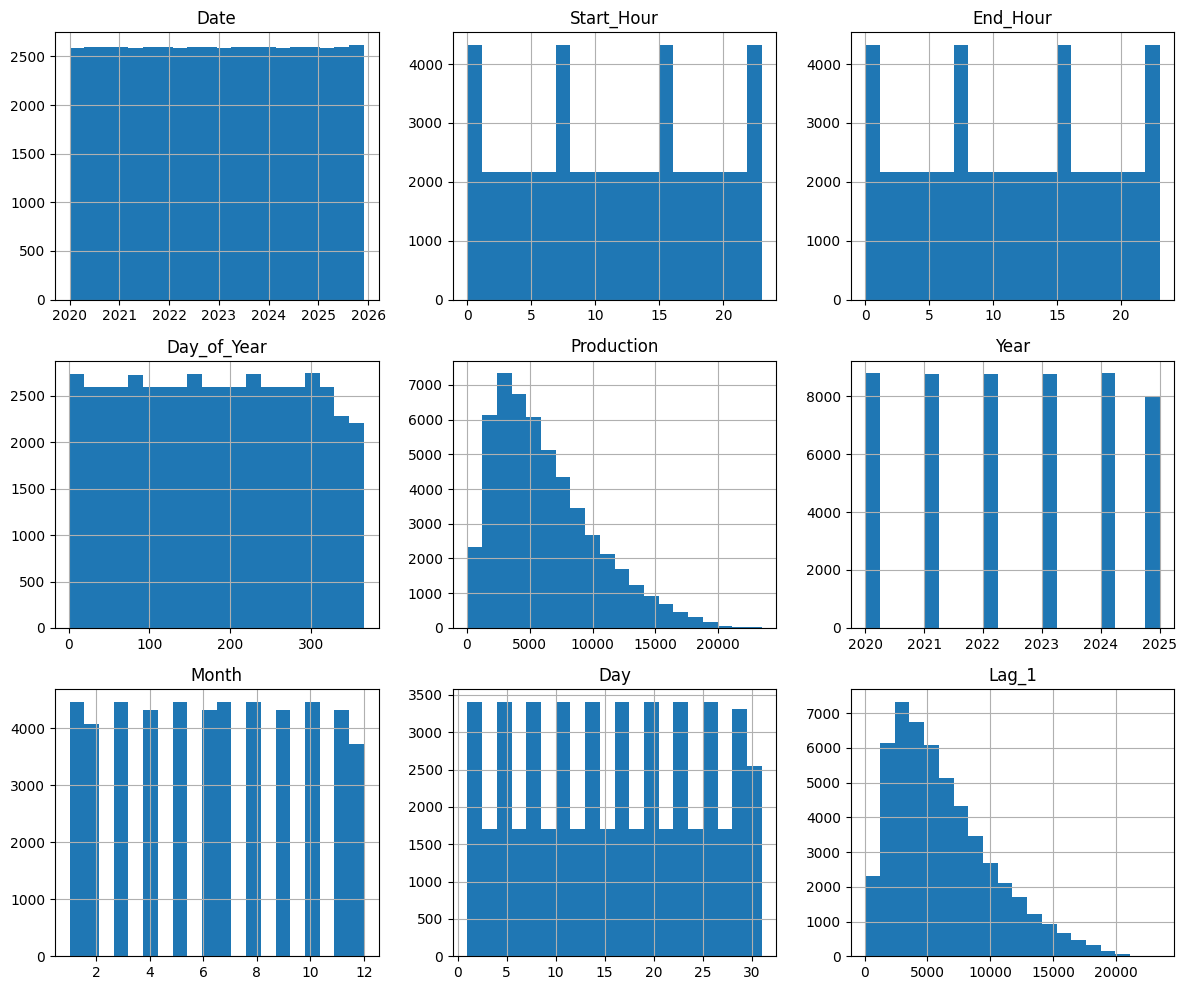

In [86]:

df.hist(figsize=(12,10), bins=20)

plt.tight_layout()

plt.show()

# Distribution of Numerical Features

Visualize the distribution of numerical variables.

In [87]:
numeric_df = df.select_dtypes(include=["number"])

# Correlation Heatmap

Analyze the correlation between numerical features and the target variable.

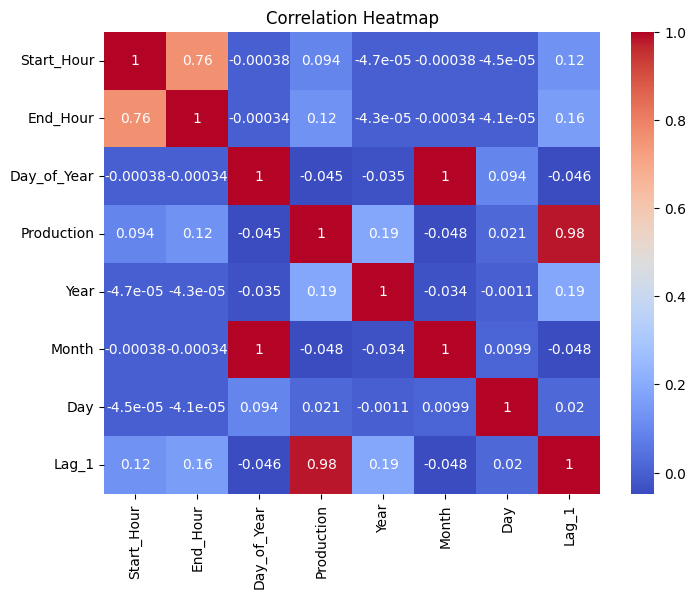

In [88]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Feature Engineering

Extract useful information from the Date column.

In [89]:
df["Date"] = pd.to_datetime(df["Date"])

In [90]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Remove Original Date

Drop the original Date column after extracting useful features.

In [91]:
df.drop("Date", axis=1, inplace=True)

# Encode Categorical Features

Convert categorical variables into numerical values using Label Encoding.

In [92]:
encoder = LabelEncoder()

df["Source"] = encoder.fit_transform(df["Source"])
df["Day_Name"] = encoder.fit_transform(df["Day_Name"])
df["Month_Name"] = encoder.fit_transform(df["Month_Name"])
df["Season"] = encoder.fit_transform(df["Season"])

In [93]:
X = df.drop(columns=["Production", "Date"], errors="ignore")
y = df["Production"]

# Define Features and Target

Separate the input features (X) from the target variable (y).

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train the Random Forest Model

Train the Random Forest Regressor using the training data.

In [95]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [96]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [97]:
y_pred = model.predict(X_test)

In [98]:
y_pred

array([ 2318.61,  2063.26,  4638.47, ...,  2332.41,  1469.57, 11079.75],
      shape=(10373,))

# Model Evaluation

Evaluate the model using MAE, RMSE, and R² Score.

In [99]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 610.7951960312649


In [100]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 377.42883543815674


In [101]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

RMSE: 610.7951960312649


In [102]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9762788767707312


# Actual vs Predicted Values

Compare the actual production values with the predicted values.

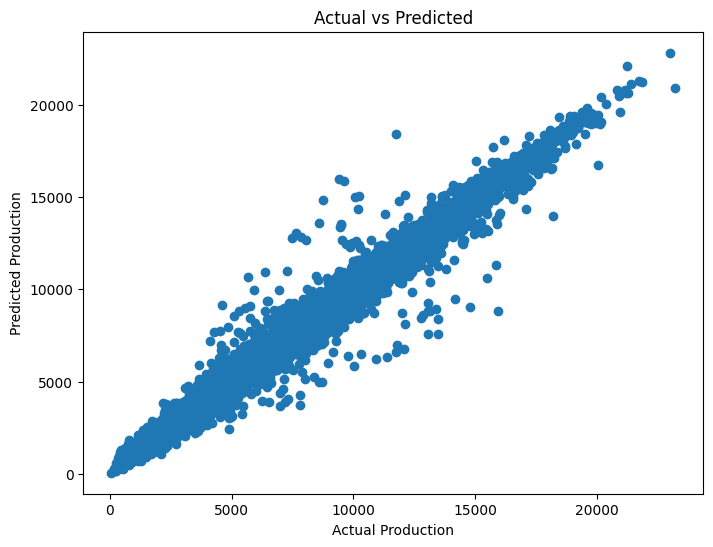

In [103]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted")

plt.show()

In [104]:
df["Production"].describe()

count    51863.000000
mean      6215.121474
std       3978.386005
min         58.000000
25%       3111.000000
50%       5372.000000
75%       8501.000000
max      23446.000000
Name: Production, dtype: float64

In [105]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
10,Lag_1,0.968429
1,End_Hour,0.010500
3,Day_of_Year,0.005303
0,Start_Hour,0.004085
9,Day,0.003084
7,Year,0.002518
5,Month_Name,0.001911
4,Day_Name,0.001852
2,Source,0.000884
8,Month,0.000761


## Observations

1. Wind energy appears more frequently than solar energy in the dataset.
2. Production values vary significantly across different seasons.
3. No missing values were found in the dataset.
4. The correlation heatmap shows that some numerical features have a stronger relationship with Production than others.
5. The distribution of Production is not perfectly symmetric and contains high-value observations.

## Conclusion

In this project, I learned how to build a renewable energy forecasting model using machine learning. I performed data exploration, preprocessing, feature encoding, model training, and evaluation.

The main challenge was preparing the data and selecting the appropriate preprocessing steps before training the model.

The model achieved an R² score of approximately 0.87, indicating good predictive performance. In the future, the model could be improved by using One-Hot Encoding, tuning the Random Forest hyperparameters, or trying more advanced regression models.